# 1. Scenario Definition and Problem Framing

This notebook starts the thesis from the system we want to operate, not from an abstract parameter sweep. The question is simple: given a fixed 3GPP-compliant micro-cell deployment and a small set of PA options on each transmit chain, how should the network allocate compliant PHY resources so that active PA energy is minimized while user service is still met?


## 1. Problem statement

The narrative for the rest of the notebook set is:

- Mobile-network energy consumption matters at system level.
- The PA is a large and controllable share of that energy budget.
- Mixed-PA hardware on one PHY chain has already been shown to work in compliant NR systems.
- The remaining thesis question is operational: when demand arrives, which resource allocation should the network choose so that active PA energy is as low as possible?


In [5]:
import sys
from pathlib import Path
from IPython.display import display

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent

for path in (repo_root / "notebooks", repo_root / "src"):
    resolved = str(path.resolve())
    if resolved not in sys.path:
        sys.path.insert(0, resolved)

from helpers.candidate_space_helpers import plot_pa_operating_curves
from helpers.scenario_definition_helpers import build_scenario_definition_artifacts

artifacts = build_scenario_definition_artifacts(
    distance_m=200.0,
    required_rate_bps=120e6,
)


In [6]:
display(artifacts.problem_statement)
display(artifacts.radio_assumptions)
display(artifacts.illustrative_user)


,question,answer
0,What is fixed?,"The scenario, PA catalog, and compliant PHY se..."
1,What is allocated?,Each active user receives a scheduler-facing r...
2,What is optimized?,The active PA energy consumption is minimized ...


,group,assumption,value
0,Deployment,Scenario,3GPP-compliant micro cell in band n78
1,Deployment,Carrier frequency,3.5 GHz
2,Deployment,Channel bandwidth,100 MHz
3,Propagation,Path-loss model,umi_sc_nlos
4,Propagation,BS / UE heights,10.0 m / 1.5 m
5,Propagation,Antenna gains,"8.0 dB TX, 0.0 dB RX"
6,Noise,Noise density and NF,"-174 dBm/Hz, 5.0 dB NF"
7,Noise,Implementation and shadow margins,"3.0 dB impl., 4.0 dB shadow"
8,Frame,Subcarrier spacing,30 kHz
9,Frame,Slot duration,0.5 ms


,distance_m,required_rate_mbps,resolved_path_loss_db,role
0,200.0,120.0,119.228841,Illustrative user condition carried into the l...


## 2. Hardware options and compliant resource space

The study assumes one 4-MIMO sub-array whose four chains are active for transmission. Each chain can use one of two measured NR PA families. The resource-allocation story does not keep every internal solver column; it keeps the scheduler-facing axes that still matter when users are later mapped onto stored operating rows.


In [7]:
display(
    artifacts.pa_characteristics[
        ["pa_id", "scenario_label", "pa_name", "p_max_w", "p_idle_w", "eta_max", "backoff_db"]
    ]
)
display(artifacts.phy_resource_space)


,pa_id,scenario_label,pa_name,p_max_w,p_idle_w,eta_max,backoff_db
0,0,8W PA,Bae et al. NR,7.928899,3.8400,0.418165,6.0
1,1,4W PA,QPA9942,1.784671,0.4215,0.352236,6.0


,dimension,admitted_values,note
0,bandwidth_hz,"50 MHz, 100 MHz",Bandwidth part choices preserved in the schedu...
1,n_prb,5-PRB grid up to the bandwidth-specific BWP limit,The candidate space walks the PRB axis in fixe...
2,layers,"1, 2, 3, 4",The active layer count is bounded by the 4-cha...
3,mcs,0 to 28,The NR MCS reference table fixes the admissibl...
4,n_slots,1 to 20 active slots,The later stored table keeps only full-frame r...
5,Stored table columns,"bandwidth_hz, n_prb, layers, mcs, rate_active_...",This is the lean contract reused by user assig...


## 3. PA behavior and the bridge to candidate generation

The measured PA curves explain why the allocation problem is worth solving at all: the energy cost is not constant across operating points, and the PA choice interacts with the occupied bandwidth, spatial layers, and required power. The final table in this notebook is therefore not yet an answer. It only defines the search envelope that later notebooks will turn into stored candidate rows.


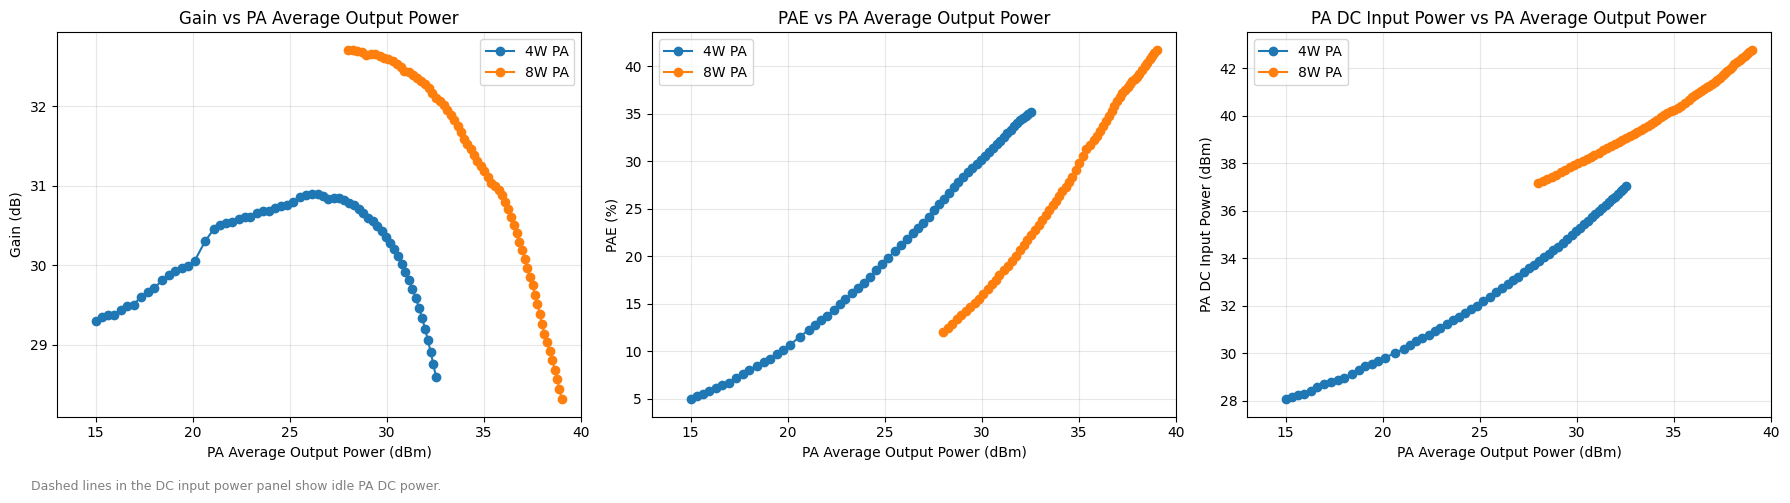

,pa_labels,bandwidth_options_hz,max_prbs_by_bwp,slot_domain,layer_domain,mcs_domain,prb_step,raw_candidate_count_per_pa,raw_candidate_count_total,raw_candidate_count_across_scenarios
0,"(8W PA, 4W PA)","(50000000.0, 100000000.0)","((8W PA, 1, 138), (8W PA, 0, 277), (4W PA, 1, ...","(1, 20)","(1, 4)","(0, 28)",5,"((8W PA, 194880), (4W PA, 194880))",389760,389760


In [8]:
plot_pa_operating_curves(artifacts.pa_curve_table)
display(artifacts.candidate_space_view)


This notebook fixes the scenario and the decision space. The next notebook moves from this fixed setting to the candidate space itself, and the one after that turns the full-frame feasible rows into the precomputed table that later notebooks will assign to users.
